In [ ]:
# %pip install shap dotenv

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# ============================================================
# NOTEBOOK 08 — SHAP + MOTOR DE ALERTAS
# VitalRisk AI · Equipo 326
# HU14 (SHAP — explicabilidad) + HU15 (alertas_territoriales)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
import pickle
import json
import warnings
from pathlib import Path
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os

warnings.filterwarnings('ignore')
load_dotenv('../.env')

PROCESSED = Path("../data/processed")
MODELS    = Path("../data/models")

C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cargar artefacto del modelo
with open(MODELS / "modelo_xgboost_vitalrisk.pkl", 'rb') as f:
    artefacto = pickle.load(f)

modelo   = artefacto['modelo']
FEATURES = artefacto['features']
fill_vals = artefacto['fill_values']
fi_dict  = artefacto['feature_importance']

In [3]:
# Cargar datos
df = pd.read_csv(PROCESSED / "fact_riesgo_territorial_ipt.csv",
                 dtype={'codigo_dane': str})
df['fecha_semana'] = pd.to_datetime(df['fecha_semana'])
df = df.sort_values(['codigo_dane','anio','semana_epi']).reset_index(drop=True)

# Reconstruir las features de ingeniería (igual que NB07)
df['semana_sin'] = np.sin(2 * np.pi * df['semana_epi'] / 52)
df['semana_cos'] = np.cos(2 * np.pi * df['semana_epi'] / 52)

In [4]:
media_hist = (
    df[df['anio'] <= 2020]
    .groupby(['codigo_dane','semana_epi'])['casos_ira_total']
    .mean().reset_index()
    .rename(columns={'casos_ira_total': 'media_hist_mun_sem'})
)
df = df.merge(media_hist, on=['codigo_dane','semana_epi'], how='left')
media_mun = (df[df['anio']<=2020]
             .groupby('codigo_dane')['casos_ira_total'].mean()
             .reset_index().rename(columns={'casos_ira_total':'media_mun_global'}))
df = df.merge(media_mun, on='codigo_dane', how='left')
df['media_hist_mun_sem'] = df['media_hist_mun_sem'].fillna(df['media_mun_global'])
df = df.drop(columns=['media_mun_global'])

In [5]:
df['desviacion_vs_historico'] = np.where(
    df['media_hist_mun_sem'] > 0,
    (df['casos_ira_total'] - df['media_hist_mun_sem'])
    / df['media_hist_mun_sem'] * 100, 0)
df['municipio_id'] = df['codigo_dane'].astype('category').cat.codes
df['target_casos_t1'] = df.groupby('codigo_dane')['casos_ira_total'].shift(-1)
df_model = df.dropna(subset=['target_casos_t1']).copy()

In [6]:
# Preparar X completo para SHAP
X_all = df_model[FEATURES].copy()
for col, val in fill_vals.items():
    if col in X_all.columns:
        X_all[col] = X_all[col].fillna(val)

print(f"Dataset para SHAP: {X_all.shape}")
print(f"Features: {FEATURES}")

Dataset para SHAP: (807, 12)
Features: ['media_hist_mun_sem', 'casos_ira_total', 'casos_ira_lag1', 'humedad_avg', 'desviacion_vs_historico', 'pm25_lag1', 'pm25_avg', 'icv_seg_social', 'icv_score', 'ipm_pct', 'semana_sin', 'semana_cos']


## 8. Explicabilidad SHAP (HU14)

### 8.1 Cálculo de SHAP values
### 8.2 SHAP global — importancia y dirección
### 8.3 SHAP local — ejemplo de predicción individual
### 8.4 Variable causal por registro

In [7]:
# ── 8.1 Cálculo de SHAP values ────────────────────────────
# TreeExplainer es el método eficiente para XGBoost.
# Calcula la contribución exacta de cada feature a cada predicción.

print("Calculando SHAP values (puede tardar ~30s)...")
explainer   = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_all)  # shape: (n_filas, n_features)

print(f"SHAP values calculados: {shap_values.shape}")
print(f"Valor esperado (base value): {explainer.expected_value:.4f} casos")
print(f"(Es el promedio global de predicciones del modelo)")

Calculando SHAP values (puede tardar ~30s)...
SHAP values calculados: (807, 12)
Valor esperado (base value): 3.2665 casos
(Es el promedio global de predicciones del modelo)


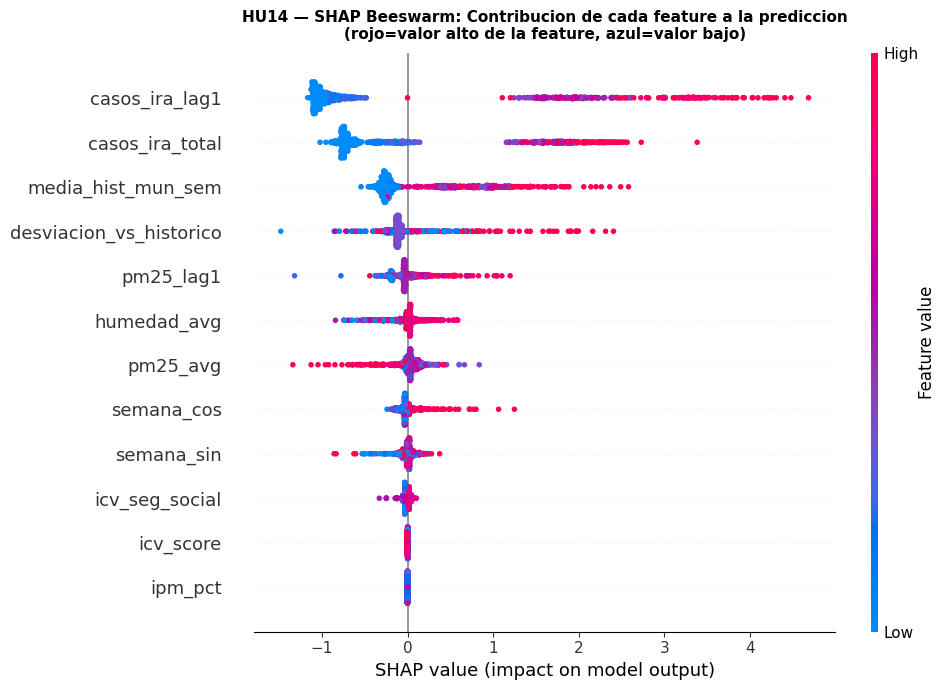


Interpretacion:
  casos_ira_lag1 ALTO (rojo) → prediccion MAS ALTA (SHAP > 0)
  icv_seg_social BAJO (azul) → prediccion MAS ALTA (peor seg. social = mas riesgo)


In [8]:
# ── 8.2 SHAP global — beeswarm plot ───────────────────────
# El beeswarm muestra:
# - Eje X: valor SHAP (contribución a la predicción)
# - Color: valor real de la feature (rojo=alto, azul=bajo)
# - Cada punto es un registro del dataset

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_all,
    feature_names=FEATURES,
    show=False,
    plot_size=(10, 7),
    max_display=12
)
plt.title('HU14 — SHAP Beeswarm: Contribucion de cada feature a la prediccion\n'
          '(rojo=valor alto de la feature, azul=valor bajo)',
          fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(PROCESSED / 'plots/nb08_shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nInterpretacion:")
print("  casos_ira_lag1 ALTO (rojo) → prediccion MAS ALTA (SHAP > 0)")
print("  icv_seg_social BAJO (azul) → prediccion MAS ALTA (peor seg. social = mas riesgo)")

=== IMPORTANCIA GLOBAL SHAP (mean |SHAP value|) ===

                feature  mean_shap
         casos_ira_lag1   1.363470
        casos_ira_total   0.924443
     media_hist_mun_sem   0.461224
desviacion_vs_historico   0.212778
              pm25_lag1   0.119861
            humedad_avg   0.105761
               pm25_avg   0.105421
             semana_cos   0.070091
             semana_sin   0.054852
         icv_seg_social   0.029114
              icv_score   0.002017
                ipm_pct   0.000000


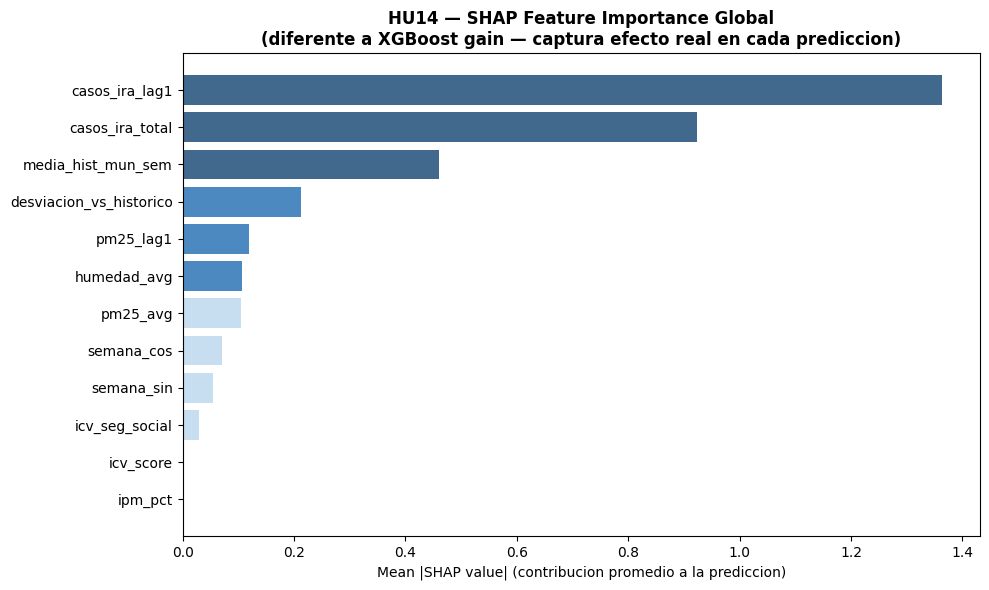

In [9]:
# ── SHAP bar chart — importancia global media |SHAP| ──────
shap_mean = pd.DataFrame({
    'feature':    FEATURES,
    'mean_shap':  np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False)

print("=== IMPORTANCIA GLOBAL SHAP (mean |SHAP value|) ===\n")
print(shap_mean.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1F4E79' if i < 3 else '#2E75B6' if i < 6 else '#BDD7EE'
          for i in range(len(shap_mean))]
ax.barh(shap_mean['feature'][::-1], shap_mean['mean_shap'][::-1],
        color=colors[::-1], alpha=0.85)
ax.set_xlabel('Mean |SHAP value| (contribucion promedio a la prediccion)')
ax.set_title('HU14 — SHAP Feature Importance Global\n'
             '(diferente a XGBoost gain — captura efecto real en cada prediccion)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED / 'plots/nb08_shap_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

=== EJEMPLO SHAP LOCAL — brote mas severo predicho ===

Registro: indice 175
Municipio: 05001
Año/Semana: 2021 / 32
Casos reales t+1:  13
Prediccion modelo: 12.71
Base value (media global): 3.2665


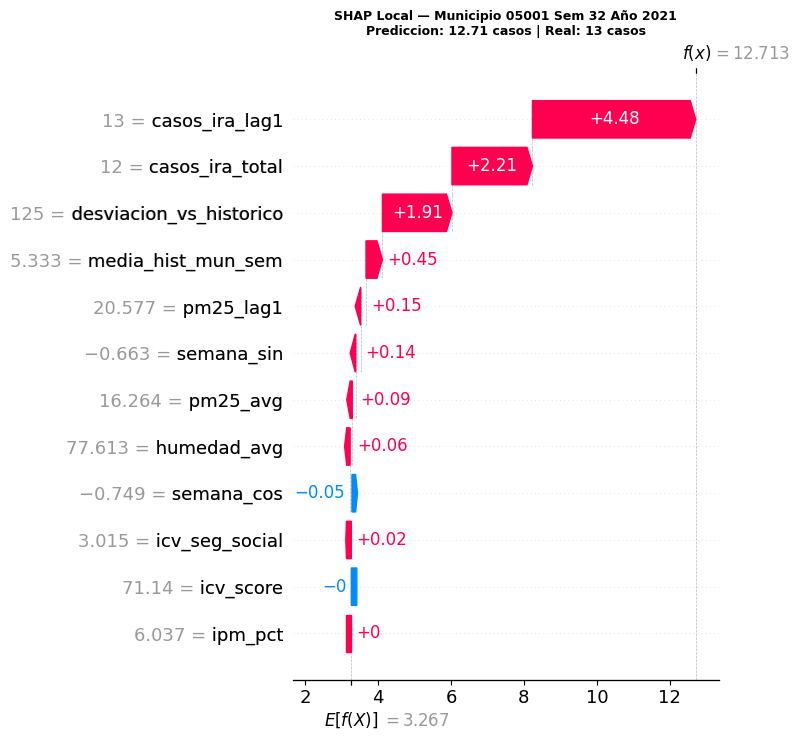

In [10]:
# ── 8.3 SHAP local — ejemplo de prediccion individual ─────
# Mostramos la explicacion para el registro con prediccion mas alta
# (el brote mas severo predicho por el modelo)

pred_all = modelo.predict(X_all)
idx_max  = np.argmax(pred_all)

print(f"=== EJEMPLO SHAP LOCAL — brote mas severo predicho ===\n")
print(f"Registro: indice {idx_max}")
print(f"Municipio: {df_model.iloc[idx_max]['codigo_dane']}")
print(f"Año/Semana: {df_model.iloc[idx_max]['anio']} / {df_model.iloc[idx_max]['semana_epi']}")
print(f"Casos reales t+1:  {df_model.iloc[idx_max]['target_casos_t1']:.0f}")
print(f"Prediccion modelo: {pred_all[idx_max]:.2f}")
print(f"Base value (media global): {explainer.expected_value:.4f}")

# Waterfall plot local
shap_exp = shap.Explanation(
    values=shap_values[idx_max],
    base_values=explainer.expected_value,
    data=X_all.iloc[idx_max].values,
    feature_names=FEATURES
)
fig, ax = plt.subplots(figsize=(10, 6))
shap.waterfall_plot(shap_exp, show=False, max_display=12)
plt.title(f'SHAP Local — Municipio {df_model.iloc[idx_max]["codigo_dane"]} '
          f'Sem {df_model.iloc[idx_max]["semana_epi"]} Año {df_model.iloc[idx_max]["anio"]}\n'
          f'Prediccion: {pred_all[idx_max]:.2f} casos | Real: {df_model.iloc[idx_max]["target_casos_t1"]:.0f} casos',
          fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED / 'plots/nb08_shap_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ── 8.4 Variable causal por registro ──────────────────────
# Para cada registro calculamos cuál feature tuvo el mayor
# |SHAP value| positivo (contribuye más a aumentar la prediccion).
# Esta es la variable_causal que va a alertas_territoriales.

shap_df = pd.DataFrame(shap_values, columns=FEATURES,
                       index=df_model.index)

# Variable causal = feature con mayor SHAP positivo
# Si todos los SHAP son negativos (prediccion baja), variable_causal = 'ninguna'
def get_variable_causal(row):
    positivos = row[row > 0]
    if len(positivos) == 0:
        return 'ninguna'
    return positivos.idxmax()

df_model = df_model.copy()
df_model['variable_causal'] = shap_df.apply(get_variable_causal, axis=1)
df_model['shap_max_value']  = shap_df.apply(
    lambda r: r[r > 0].max() if (r > 0).any() else 0, axis=1)
df_model['prediccion_casos_t1'] = np.clip(pred_all, 0, None).round(2)

print("=== TOP 10 VARIABLES CAUSALES MAS FRECUENTES ===\n")
print(df_model['variable_causal'].value_counts().head(10).to_string())

print(f"\n=== EJEMPLOS DE VARIABLE CAUSAL POR MUNICIPIO ===")
sample = df_model[['codigo_dane','anio','semana_epi',
                   'prediccion_casos_t1','variable_causal',
                   'shap_max_value']].head(10)
print(sample.to_string(index=False))

=== TOP 10 VARIABLES CAUSALES MAS FRECUENTES ===

variable_causal
pm25_avg                   205
casos_ira_lag1             168
humedad_avg                103
casos_ira_total             79
pm25_lag1                   74
media_hist_mun_sem          56
semana_cos                  38
semana_sin                  31
desviacion_vs_historico     20
icv_score                   19

=== EJEMPLOS DE VARIABLE CAUSAL POR MUNICIPIO ===
codigo_dane  anio  semana_epi  prediccion_casos_t1    variable_causal  shap_max_value
      05001  2018           1                 7.63    casos_ira_total        2.255135
      05001  2018           2                 6.78     casos_ira_lag1        1.541348
      05001  2018           3                 6.11     casos_ira_lag1        1.501359
      05001  2018           4                 6.54     casos_ira_lag1        1.606391
      05001  2018           5                 5.63     casos_ira_lag1        1.974756
      05001  2018           6                 5.47 media_

## 9. Motor de Alertas (HU15)

### 9.1 Lógica de generación de alertas
### 9.2 Generación del dataset de alertas
### 9.3 Carga en alertas_territoriales (PostGIS)
### 9.4 Verificación final

In [12]:
# ── 9.1 Lógica de alertas ─────────────────────────────────
# Umbral definido en NB05 (HU9): percentil 92 = 30% sobre media histórica
# 
# ALERTA_VERDE:   desviacion_predicha < 30%  (comportamiento normal)
# ALERTA_NARANJA: 30% <= desviacion < 60%    (riesgo moderado)
# ALERTA_ROJA:    desviacion >= 60%           (brote probable)
#
# La desviacion se calcula comparando la PREDICCION del modelo
# contra la media historica del municipio en esa semana del año.
# Así el sistema anticipa brotes ANTES de que ocurran.

UMBRAL_NARANJA = 30.0  # % sobre media historica (percentil 92 — NB05)
UMBRAL_ROJA    = 60.0  # % sobre media historica (umbral severo)

def calcular_nivel_alerta(desv_pct):
    """
    Clasifica el nivel de alerta según la desviacion porcentual
    de la prediccion respecto a la media historica municipal.
    """
    if desv_pct >= UMBRAL_ROJA:
        return 'ALERTA_ROJA'
    elif desv_pct >= UMBRAL_NARANJA:
        return 'ALERTA_NARANJA'
    else:
        return 'ALERTA_VERDE'

print("=== LOGICA DE ALERTAS ===\n")
print(f"  ALERTA_VERDE:   desviacion < {UMBRAL_NARANJA}%  → comportamiento esperado")
print(f"  ALERTA_NARANJA: {UMBRAL_NARANJA}% <= desviacion < {UMBRAL_ROJA}%  → monitoreo activo")
print(f"  ALERTA_ROJA:    desviacion >= {UMBRAL_ROJA}%          → activar protocolo preventivo")
print(f"\n  Umbral NARANJA justificado en NB05: percentil 92 = 30% sobre media historica")
print(f"  Umbral ROJA: doble del NARANJA — desviacion severa")

=== LOGICA DE ALERTAS ===

  ALERTA_VERDE:   desviacion < 30.0%  → comportamiento esperado
  ALERTA_NARANJA: 30.0% <= desviacion < 60.0%  → monitoreo activo
  ALERTA_ROJA:    desviacion >= 60.0%          → activar protocolo preventivo

  Umbral NARANJA justificado en NB05: percentil 92 = 30% sobre media historica
  Umbral ROJA: doble del NARANJA — desviacion severa


In [13]:
# ── 9.2 Generación del dataset de alertas ─────────────────
# La desviacion se calcula sobre la PREDICCION (t+1), no sobre casos actuales.
# Esto es lo que diferencia a VitalRisk AI de un sistema reactivo.

df_alertas = df_model[['codigo_dane','anio','semana_epi',
                        'fecha_semana','media_hist_mun_sem',
                        'prediccion_casos_t1','variable_causal',
                        'shap_max_value']].copy()

# Desviacion de la PREDICCION vs media historica
df_alertas['desviacion_prediccion_pct'] = np.where(
    df_alertas['media_hist_mun_sem'] > 0,
    (df_alertas['prediccion_casos_t1'] - df_alertas['media_hist_mun_sem'])
    / df_alertas['media_hist_mun_sem'] * 100,
    0
).round(2)

# Nivel de alerta
df_alertas['nivel_alerta'] = df_alertas['desviacion_prediccion_pct'].apply(
    calcular_nivel_alerta)

# Timestamp de generacion de la alerta
df_alertas['fecha_generacion'] = pd.Timestamp.now().isoformat()

# Resumen
print("=== DISTRIBUCION DE ALERTAS GENERADAS ===\n")
dist = df_alertas['nivel_alerta'].value_counts()
print(dist.to_string())
print(f"\nTotal alertas: {len(df_alertas):,}")
print(f"\nAlertas ROJAS por municipio (top 10):")
rojas = (df_alertas[df_alertas['nivel_alerta']=='ALERTA_ROJA']
         .groupby('codigo_dane').size()
         .sort_values(ascending=False).head(10))
print(rojas.to_string())

=== DISTRIBUCION DE ALERTAS GENERADAS ===

nivel_alerta
ALERTA_VERDE      657
ALERTA_NARANJA     84
ALERTA_ROJA        66

Total alertas: 807

Alertas ROJAS por municipio (top 10):
codigo_dane
05001    59
05088     4
05079     1
05360     1
05380     1


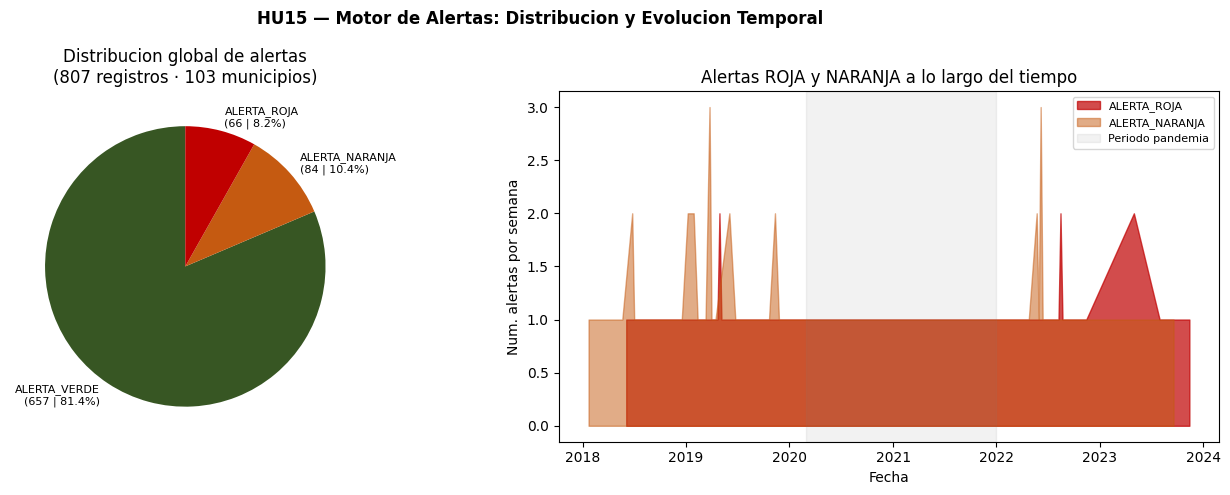

In [14]:
# ── Visualizacion de alertas ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HU15 — Motor de Alertas: Distribucion y Evolucion Temporal',
             fontsize=12, fontweight='bold')

# Pie chart distribución
colores_alerta = {
    'ALERTA_VERDE':   '#375623',
    'ALERTA_NARANJA': '#C55A11',
    'ALERTA_ROJA':    '#C00000'
}
dist_vals  = [dist.get(k, 0) for k in colores_alerta]
dist_cols  = list(colores_alerta.values())
dist_labs  = [f"{k}\n({v} | {v/len(df_alertas)*100:.1f}%)"
              for k, v in zip(colores_alerta.keys(), dist_vals)]
axes[0].pie(dist_vals, labels=dist_labs, colors=dist_cols,
            autopct='', startangle=90,
            textprops={'fontsize': 8})
axes[0].set_title('Distribucion global de alertas\n(807 registros · 103 municipios)')

# Serie temporal de alertas ROJAS por semana
df_alertas['semana_fecha'] = pd.to_datetime(df_alertas['fecha_semana'])
rojas_tiempo = (df_alertas[df_alertas['nivel_alerta']=='ALERTA_ROJA']
                .groupby('semana_fecha').size())
naranjas_tiempo = (df_alertas[df_alertas['nivel_alerta']=='ALERTA_NARANJA']
                   .groupby('semana_fecha').size())

ax = axes[1]
ax.fill_between(rojas_tiempo.index, rojas_tiempo.values,
                alpha=0.7, color='#C00000', label='ALERTA_ROJA')
ax.fill_between(naranjas_tiempo.index, naranjas_tiempo.values,
                alpha=0.5, color='#C55A11', label='ALERTA_NARANJA')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
           alpha=0.1, color='gray', label='Periodo pandemia')
ax.set_xlabel('Fecha')
ax.set_ylabel('Num. alertas por semana')
ax.set_title('Alertas ROJA y NARANJA a lo largo del tiempo')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PROCESSED / 'plots/nb08_alertas_distribucion.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── 9.3 Exportar CSV para el ETL ──────────────────────────
cols_exportar = [
    'codigo_dane','anio','semana_epi','fecha_semana',
    'nivel_alerta','prediccion_casos_t1',
    'desviacion_prediccion_pct','variable_causal',
    'media_hist_mun_sem','shap_max_value'
]

ruta_alertas = PROCESSED / "alertas_territoriales.csv"
df_alertas[cols_exportar].to_csv(ruta_alertas, index=False)

print(f"✓ Exportado: {ruta_alertas}")
print(f"  {len(df_alertas):,} filas × {len(cols_exportar)} columnas")
print(f"  ALERTA_ROJA:    {(df_alertas['nivel_alerta']=='ALERTA_ROJA').sum()}")
print(f"  ALERTA_NARANJA: {(df_alertas['nivel_alerta']=='ALERTA_NARANJA').sum()}")
print(f"  ALERTA_VERDE:   {(df_alertas['nivel_alerta']=='ALERTA_VERDE').sum()}")
print(f"\n→ Ejecutar load_to_db.py para cargar en PostGIS")

✓ Exportado: ..\data\processed\alertas_territoriales.csv
  807 filas × 10 columnas
  ALERTA_ROJA:    66
  ALERTA_NARANJA: 84
  ALERTA_VERDE:   657

→ Ejecutar load_to_db.py para cargar en PostGIS


In [16]:
# ── 9.4 Verificación del CSV exportado ────────────────────
df_check = pd.read_csv(PROCESSED / "alertas_territoriales.csv",
                       dtype={'codigo_dane': str})

print("=== VERIFICACION DEL CSV EXPORTADO ===\n")
print(f"  Filas:    {len(df_check):,}")
print(f"  Columnas: {list(df_check.columns)}")
print(f"  Nulos en nivel_alerta:    {df_check['nivel_alerta'].isna().sum()}")
print(f"  Nulos en variable_causal: {df_check['variable_causal'].isna().sum()}")
print(f"\n  Distribucion:")
print(df_check['nivel_alerta'].value_counts().to_string())
print(f"\n  Top variables causales:")
print(df_check['variable_causal'].value_counts().head(5).to_string())

print(f"\n=== CRITERIOS DE ACEPTACION HU14 + HU15 ===")
print(f"  HU14 — SHAP values calculados:     ✓")
print(f"  HU14 — variable_causal por fila:   ✓")
print(f"  HU14 — beeswarm + waterfall plots: ✓")
print(f"  HU15 — alertas CSV generado:       ✓ ({len(df_check):,} filas)")
print(f"  HU15 — tres niveles de alerta:     ✓")
print(f"  HU15 — umbral 30% = percentil 92:  ✓")
print(f"  HU15 — carga via load_to_db.py:    → pendiente ejecutar ETL")

=== VERIFICACION DEL CSV EXPORTADO ===

  Filas:    807
  Columnas: ['codigo_dane', 'anio', 'semana_epi', 'fecha_semana', 'nivel_alerta', 'prediccion_casos_t1', 'desviacion_prediccion_pct', 'variable_causal', 'media_hist_mun_sem', 'shap_max_value']
  Nulos en nivel_alerta:    0
  Nulos en variable_causal: 0

  Distribucion:
nivel_alerta
ALERTA_VERDE      657
ALERTA_NARANJA     84
ALERTA_ROJA        66

  Top variables causales:
variable_causal
pm25_avg           205
casos_ira_lag1     168
humedad_avg        103
casos_ira_total     79
pm25_lag1           74

=== CRITERIOS DE ACEPTACION HU14 + HU15 ===
  HU14 — SHAP values calculados:     ✓
  HU14 — variable_causal por fila:   ✓
  HU14 — beeswarm + waterfall plots: ✓
  HU15 — alertas CSV generado:       ✓ (807 filas)
  HU15 — tres niveles de alerta:     ✓
  HU15 — umbral 30% = percentil 92:  ✓
  HU15 — carga via load_to_db.py:    → pendiente ejecutar ETL
